# Input Generation — Base Household Demand (H25, 4,500 kWh/year, 2026)

## Purpose

This notebook generates the **15-minute base household electricity demand time series** used across all eight household archetypes in the thesis simulation. The output represents standard residential electricity consumption (lighting, appliances) excluding all §14a-controllable devices (heat pump, EV, battery storage).

**Raw input file:** `raw-data/BDEW_Standardlastprofile_Strom_retrieved_2026-02.xlsx`  
**Output file:** `inputs/base_demand_h25_4500kwh_2026_15min.csv`

## Data source

The profile is based on the **BDEW Standardlastprofil H25** (*Haushalt 25*), the German industry-standard residential load profile published by the Bundesverband der Energie- und Wasserwirtschaft (BDEW):

> Bundesverband der Energie- und Wasserwirtschaft [BDEW]. (n.d.). *Standardlastprofile Strom: Grundlagen & Anwendung*. Retrieved April 15, 2026, from https://www.bdew.de/energie/standardlastprofile-strom/

The raw profile matrix (`raw-data/BDEW_Standardlastprofile_Strom_retrieved_2026-02.xlsx`, sheet `H25`) provides **96 quarter-hour base values per day**, differentiated by three day types — weekday (*Werktag*, WT), Saturday (*Samstag*, SA), and Sunday/public holiday (*Sonntag und Feiertage*, FT) — across 12 calendar months. Values are normalised to an annual consumption of **1,000,000 kWh/year**.

## BDEW dynamisation (*Dynamisierung*)

The BDEW specification explicitly requires that the monthly base values are multiplied by a day-of-year correction factor $f(t)$ before being used in a full-year time series (*"Bei Ausrollen der Profile ist die Dynamisierungsfunktion anzuwenden!"*, BDEW H25 sheet header). The polynomial is defined as:

$$f(t) = -3.92 \times 10^{-10}\, t^4 + 3.20 \times 10^{-7}\, t^3 - 7.02 \times 10^{-5}\, t^2 + 2.10 \times 10^{-3}\, t + 1.24$$

where $t$ is the day of the year (1-36565). This factor captures the smooth seasonal variation in residential electricity consumption not reflected in the monthly average base profile alone — it raises winter values and dampens summer values relative to the unadjusted monthly average.

## Processing steps

1. **Load** the H25 profile matrix from the BDEW Excel file.
2. **Apply BDEW dynamisation**: multiply each day's base profile by $f(t)$.
3. **Assign day types** for the 2026 calendar year (WT / SA / FT), including all German federal public holidays.
4. **Assemble** the full-year 35,040-step series.
5. **Rescale** the annual sum to the thesis target of **4,500 kWh/year**.
6. **Export** to CSV.

## Thesis reference

Chapter 3, Section 3.5.1 — *Base Demand Profile (H25)*

In [19]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker: str = "README.md") -> Path:
    """Walk upward from CWD until a marker file is found — robust regardless
    of whether Jupyter was launched from the repo root or a sub-directory."""
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f"Repo root not found (looked for: {marker})")

REPO_ROOT = find_repo_root()
RAW_DATA  = REPO_ROOT / "data" / "raw"
INPUTS    = REPO_ROOT / "inputs"
INPUTS.mkdir(parents=True, exist_ok=True)

BDEW_PATH  = RAW_DATA / "BDEW_Standardlastprofile_Strom_retrieved_2026-02.xlsx"
OUTPUT_CSV = INPUTS   / "base_demand_h25_4500kwh_2026_15min.csv"

TARGET_KWH = 4_500   # annual consumption target [kWh/year] — thesis Section 3.5.1
YEAR       = 2026
DT_H       = 0.25    # timestep [h]

assert BDEW_PATH.exists(), f"Raw file not found: {BDEW_PATH}"
print(f"BDEW source : {BDEW_PATH.name}")
print(f"Output      : {OUTPUT_CSV}")

BDEW source : BDEW_Standardlastprofile_Strom_retrieved_2026-02.xlsx
Output      : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/base_demand_h25_4500kwh_2026_15min.csv


## Step 1 — Load the H25 profile matrix

The Excel encodes the H25 base profile with two header rows (months, day types) followed by 96 rows of quarter-hour values. 

In [20]:
# # H25 sheet structure: Row 1 = title, Row 2 = empty, Row 3 = month names (merged 3 cols each),
# Row 4 = SA/FT/WT labels (becomes iloc[0] after header=[1,2]), Rows 5-100 = 96 quarter-hour values.
# Columns 0-1 are time-slot labels; columns 2-37 are the 36 data columns (3 per month, left-to-right).
h25 = pd.read_excel(BDEW_PATH, sheet_name="H25", header=[1, 2])

month_cols  = h25.columns[2:]   # 36 data columns (skip time-label and unit columns)
daytype_row = h25.iloc[0]       # SA / FT / WT labels for each column

# Build lookup: (month_int 1–12, daytype str) -> np.array of 96 kWh values
month_daytype_profile = {}
for m in range(1, 13):
    group = month_cols[(m - 1) * 3 : m * 3]   # SA, FT, WT columns for month m
    for col in group:
        label = str(daytype_row[col]).strip()
        vals  = pd.to_numeric(h25.loc[1:96, col], errors="coerce").values
        month_daytype_profile[(m, label)] = vals

print(f"Day types   : {sorted({dt for (_, dt) in month_daytype_profile})}")
print(f"Entries     : {len(month_daytype_profile)}  (12 months × 3 day types)")
print(f"Slots/entry : {len(next(iter(month_daytype_profile.values())))}")

Day types   : ['FT', 'SA', 'WT']
Entries     : 36  (12 months × 3 day types)
Slots/entry : 96


## Step 2 — BDEW dynamisation function $f(t)$

The H25 base profile stores one **average shape per month and day type** — it does not yet capture the smooth seasonal swing in electricity use within a month (e.g. colder days in early January vs. late January). The BDEW specification mandates a correction: every day's 96-slot profile shape is multiplied by a scalar $f(t)$ before being assembled into a full-year time series.

**How it is applied (Step 4):**  
For each calendar day $d$:
1. Look up the 96-slot base profile for `(month of d, day-type of d)` — values in Wh, normalised to 1 GWh/year.
2. Multiply **all 96 slots** by $f(t)$, where $t$ = day-of-year of $d$.
3. The resulting scaled profile is used as-is for that day.

The polynomial coefficients are taken verbatim from the `Dynamisierung` sheet of the BDEW Excel file.

In [21]:
# Polynomial coefficients from BDEW Dynamisierung sheet (highest to lowest degree).
# np.polyval evaluates: a[0]*t^4 + a[1]*t^3 + a[2]*t^2 + a[3]*t + a[4]
_DYNCOEFF = np.array([-3.92e-10, 3.20e-7, -7.02e-5, 2.10e-3, 1.24])

def f_dyn(day_of_year: int) -> float:
    return float(np.polyval(_DYNCOEFF, float(day_of_year)))

# Sanity check — seasonal range of f(t)
print('Dynamisation factors at key days of year:')
print(f'  (values > 1 boost the profile; < 1 dampen it relative to the monthly base)')
for doy, label in [(1, 'Jan  1'), (91, 'Apr  1'), (182, 'Jul  1'), (274, 'Oct  1'), (365, 'Dec 31')]:
    direction = 'boosted' if f_dyn(doy) > 1 else 'dampened'
    print(f'  f({doy:3d}) [{label}] = {f_dyn(doy):.4f}  -> profile {direction} by {abs(f_dyn(doy)-1)*100:.1f}%')


Dynamisation factors at key days of year:
  (values > 1 boost the profile; < 1 dampen it relative to the monthly base)
  f(  1) [Jan  1] = 1.2420  -> profile boosted by 24.2%
  f( 91) [Apr  1] = 1.0640  -> profile boosted by 6.4%
  f(182) [Jul  1] = 0.7959  -> profile dampened by 20.4%
  f(274) [Oct  1] = 0.9183  -> profile dampened by 8.2%
  f(365) [Dec 31] = 1.2572  -> profile boosted by 25.7%


## Step 3 — Assign BDEW day types for 2026

German federal public holidays for 2026 are hardcoded for transparency. State-specific holidays are excluded as the thesis uses a nationally representative profile.

In [22]:
# German federal public holidays 2026 — hardcoded for reproducibility
PUBLIC_HOLIDAYS_2026 = {
    pd.Timestamp("2026-01-01"),  # Neujahr
    pd.Timestamp("2026-04-03"),  # Karfreitag
    pd.Timestamp("2026-04-06"),  # Ostermontag
    pd.Timestamp("2026-05-01"),  # Tag der Arbeit
    pd.Timestamp("2026-05-14"),  # Christi Himmelfahrt
    pd.Timestamp("2026-05-25"),  # Pfingstmontag
    pd.Timestamp("2026-10-03"),  # Tag der Deutschen Einheit
    pd.Timestamp("2026-12-25"),  # 1. Weihnachtstag
    pd.Timestamp("2026-12-26"),  # 2. Weihnachtstag
}

def bdew_daytype(date: pd.Timestamp) -> str:
    if date.normalize() in PUBLIC_HOLIDAYS_2026 or date.weekday() == 6:
        return "FT"
    if date.weekday() == 5:
        return "SA"
    return "WT"

# Summary of day-type distribution
days = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31", freq="D")
from collections import Counter
dist = Counter(bdew_daytype(d) for d in days)
for dt, n in sorted(dist.items()):
    print(f"  {dt}: {n} days")

  FT: 61 days
  SA: 50 days
  WT: 254 days


## Step 4 — Assemble, dynamise, and rescale

In [23]:
# 35,040-slot index (96 slots/day x 365 days)
idx = pd.date_range(f"{YEAR}-01-01 00:00", f"{YEAR}-12-31 23:45", freq="15min")

# For each day: pick the right monthly base profile (by month + day type), scale by f(t).
values_wh = np.concatenate([
    month_daytype_profile[(d.month, bdew_daytype(d))] * f_dyn(d.day_of_year)
    for d in days
])
assert len(values_wh) == len(idx)

# Wh -> kWh; rescale proportionally so annual sum == 4,500 kWh exactly.
ts_kwh = pd.Series(values_wh / 1000.0, index=idx, name="demand_kwh")
ts_kwh = ts_kwh * (TARGET_KWH / ts_kwh.sum())

print(f"Timesteps  : {len(ts_kwh):,}")
print(f"Annual sum : {ts_kwh.sum():,.1f} kWh  (target: {TARGET_KWH:,} kWh)")
print(f"Mean power : {ts_kwh.mean()/DT_H*1000:.0f} W")
print(f"Peak power : {ts_kwh.max()/DT_H*1000:.0f} W")
assert abs(ts_kwh.sum() - TARGET_KWH) < 0.01

Timesteps  : 35,040
Annual sum : 4,500.0 kWh  (target: 4,500 kWh)
Mean power : 514 W
Peak power : 1029 W


## Step 5 — Visualisation

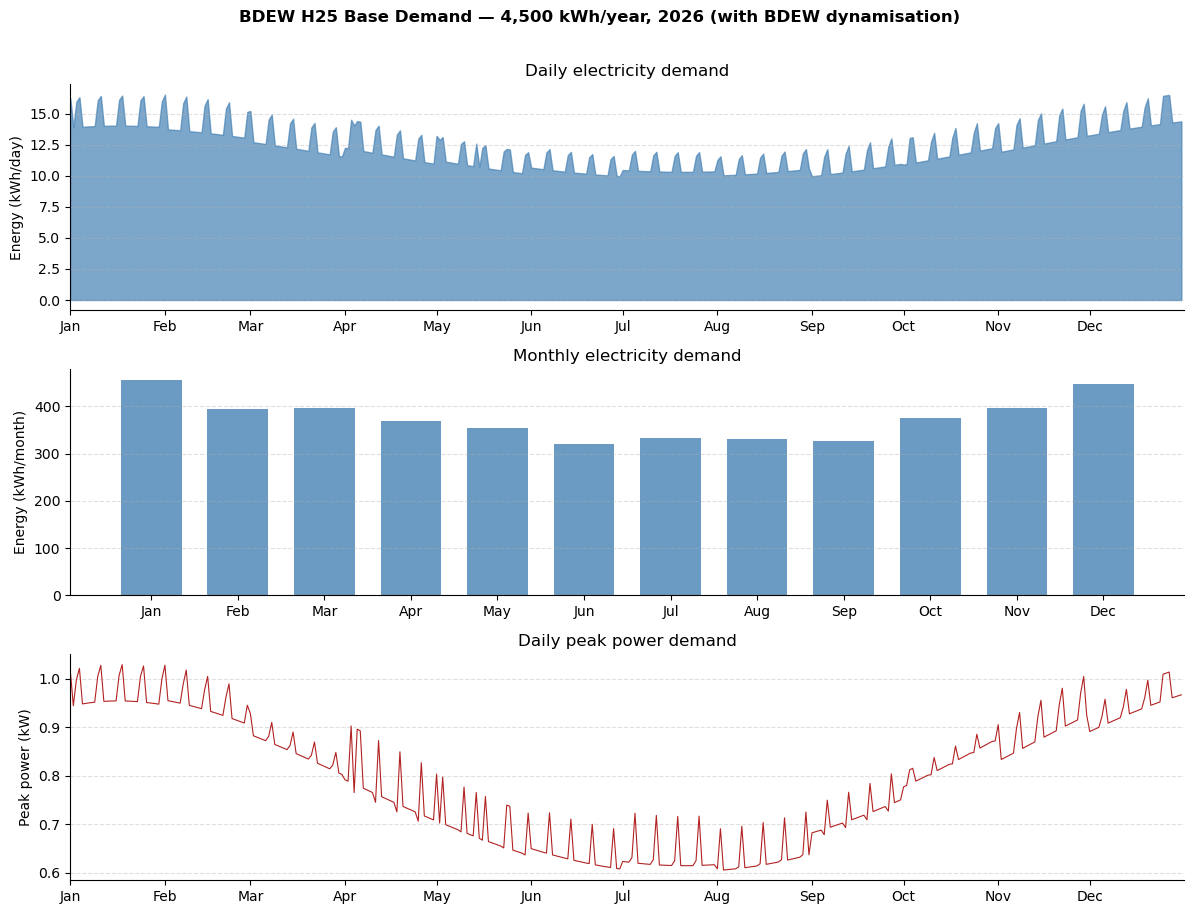

In [24]:
daily   = ts_kwh.resample("D").sum()
monthly = ts_kwh.resample("ME").sum()
peak_kw = (ts_kwh / DT_H).resample("D").max()

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle(f"BDEW H25 Base Demand — {TARGET_KWH:,} kWh/year, {YEAR} (with BDEW dynamisation)",
             fontsize=12, fontweight="bold", y=1.01)

axes[0].fill_between(daily.index, daily.values, alpha=0.7, color="steelblue")
axes[0].set_ylabel("Energy (kWh/day)")
axes[0].set_title("Daily electricity demand")

axes[1].bar(range(12), monthly.values, color="steelblue", alpha=0.8, width=0.7)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([d.strftime("%b") for d in monthly.index])
axes[1].set_ylabel("Energy (kWh/month)")
axes[1].set_title("Monthly electricity demand")

axes[2].plot(peak_kw.index, peak_kw.values, lw=0.8, color="firebrick")
axes[2].set_ylabel("Peak power (kW)")
axes[2].set_title("Daily peak power demand")

for ax in axes:
    if ax != axes[1]:
        ax.set_xlim(ts_kwh.index[0], ts_kwh.index[-1])
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Step 6 — Export to CSV

In [25]:
df_out = pd.DataFrame({
    "timestamp"  : ts_kwh.index.strftime("%Y-%m-%d %H:%M"),
    "demand_kwh" : ts_kwh.values.round(6),
})

df_out.to_csv(OUTPUT_CSV, index=False)

print(f"Exported : {OUTPUT_CSV}")
print(f"Shape    : {df_out.shape}")
print(f"Annual Σ : {df_out['demand_kwh'].sum():,.4f} kWh")
print()
print(df_out.head(6).to_string(index=False))

Exported : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/base_demand_h25_4500kwh_2026_15min.csv
Shape    : (35040, 2)
Annual Σ : 4,500.0000 kWh

       timestamp  demand_kwh
2026-01-01 00:00    0.129562
2026-01-01 00:15    0.123053
2026-01-01 00:30    0.118362
2026-01-01 00:45    0.114097
2026-01-01 01:00    0.109984
2026-01-01 01:15    0.106334
